<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_%D0%A0%D0%B5%D1%88%D0%B0%D1%8E%D1%89%D0%B8%D0%B5_%D0%B4%D0%B5%D1%80%D0%B5%D0%B2%D1%8C%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *0. Ознакомиться с [блокнотом](https://colab.research.google.com/drive/1PwN8igT5w2xArBGmM6rvO9pVRQMh-FQn?usp=sharing)

# 1. Дерево решений для классификации

In [95]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

### Получение данных

Будем работать с набором данных для задачи классификации - данные по сердечно сосудистым заболеваниям, довольно стандартный набор для изучения машинного обучения, но его нет в `sklearn'e`. Поэтому скачиваем данные со стороны, с google диска.

Ссылка на google drive: https://drive.google.com/file/d/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G


In [96]:
!wget 'https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G' -O cardio.csv

--2026-04-17 22:33:36--  https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G
Resolving drive.google.com (drive.google.com)... 173.194.212.138, 173.194.212.139, 173.194.212.100, ...
Connecting to drive.google.com (drive.google.com)|173.194.212.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download [following]
--2026-04-17 22:33:36--  https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.204.132, 2607:f8b0:400c:c04::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.204.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2941524 (2.8M) [application/octet-stream]
Saving to: ‘cardio.csv’

cardio.csv          100%[===================>]   2.80M  --.-KB

В задаче предалагается предсказать наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра. Датасет сформирован 3 групп признаков:

Объективные признаки:
- Возраст (в днях)
- Рост
- Вес
- Пол

Результаты измерения:

- Артериальное давление верхнее и нижнее
- Холестерин (три группы: норма, выше нормы, значительно выше нормы)
- Глюкоза (три группы: норма, выше нормы, значительно выше нормы)

Субъективные признаки (бинарные):

- Курение
- Употребление Алкоголя
- Физическая активность

In [97]:
import pandas as pd
df = pd.read_csv('cardio.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [100]:
full_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [101]:
df['age'] = round(df['age'] / 365)

## 1. Вводная

### 1.1 Сколько вопросов будет задано на первом этапе

Посчитайте, сколько вопросов задаст дерево решений в самый первый раз, если использовать все признаки из списка full_features.

In [102]:
questions_count = 0
for feature in full_features:
  questions_count += df[feature].nunique() - 1
print(questions_count)

710


### 1.2 Упростите задачу

Вопросов получилось достаточно, не будет моделировать столько вопросов, а попробуем уменьшить их количество.

Возьмите только два признака: weight и gluc.
А так же возьмите только 10 первых объектов.

In [103]:
features = ['weight', 'gluc']
df_small = df.loc[:9, features + [target]].copy()
df_small

,weight,gluc,cardio
0,62.0,1,0
1,85.0,1,1
2,64.0,1,1
3,82.0,1,1
4,56.0,1,0
5,67.0,2,0
6,93.0,1,0
7,95.0,3,1
8,71.0,1,0
9,68.0,1,0


### 1.3 Посчитайте еще раз, сколько будет вопросов

In [104]:
questions_count = 0
for feature in features:
  questions_count += df_small[feature].nunique() - 1
print(questions_count)

11


С таким количеством вопросов уже можем работать и разбираться в устройству дерева решений.

## 2. Устройство дерева решений

### 2.1 Обучите дерево решений

Обучите дерево решений из sklearn'a с атрибутом `random_state=1`.

In [105]:
clf = DecisionTreeClassifier(random_state=1)
clf.fit(df_small[features], df_small[target])

DecisionTreeClassifier(random_state=1)

### 2.2 Отрисуйте обученное дерево решений

Нарисуйте дерево решений, которое у вас получилось после обучения. Сделайте отрисовку такой, чтобы можно было понять, какие вопросы задаются

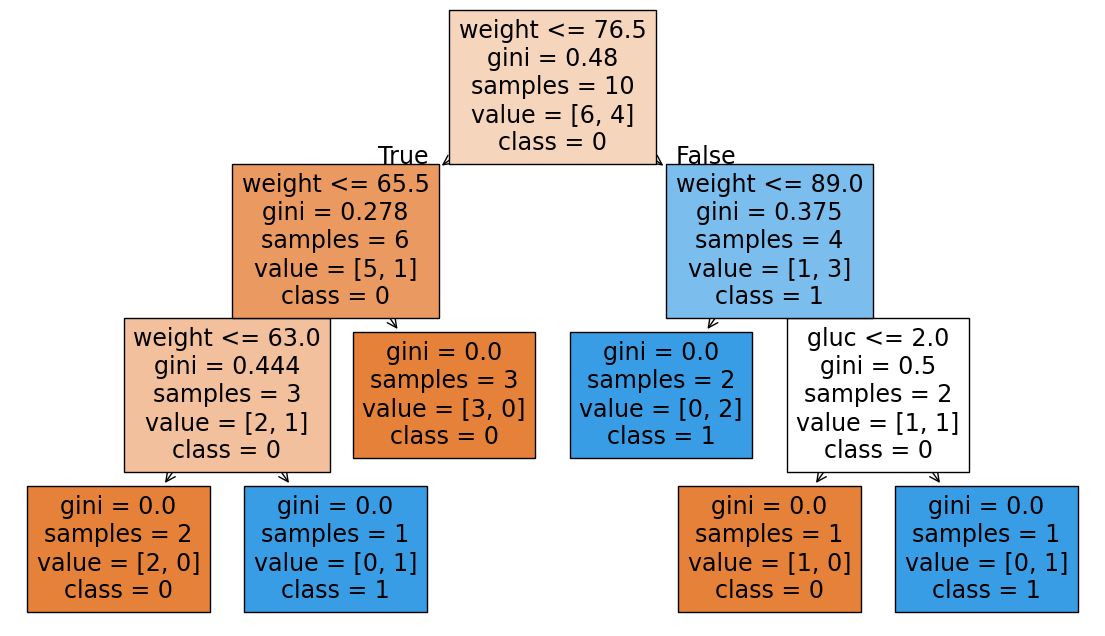

In [106]:
plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=features, class_names=['0', '1'], filled=True)
plt.show()

### 2.3 Посчитайте, сколько вершин получилось

In [107]:
print(clf.tree_.node_count)

11


### 2.4 Посчитайте, сколько листов получилось

In [108]:
print(clf.get_n_leaves())

6


### 2.5 Посмотрите, почему не получилось сделать разбиение ещё на два узла в крайнем левом узле.

В узле, где
```
gini=0.5
samples=2
value=[1, 1]
```

In [109]:
problem_df = df_small[df_small['weight'] > 89]
problem_df

,weight,gluc,cardio
6,93.0,1,0
7,95.0,3,1


Тут дальше дерево уже не стало делить автоматически, хотя в узле остались 2 объекта разных классов. Если посмотреть вручную, их можно разделить вопросом gluc <= 2.0. То есть по сути разбиение есть, просто модель на этом шаге его уже не выбрала

## 3. Вспомогательные функции

Для того, что бы дальше сравнивать между собой объекты нужно реализовать две вспомогательные функции.

### 3.1 Функция подсчета критерия Джини

Функция должна принимать список целевых значений, считать критерий информативности и выдавать одно значение - критерий Джини.

In [110]:
def gini(y):
  p = pd.Series(y).value_counts(normalize=True)
  return 1 - (p ** 2).sum()

### 3.2 Проверка функции gini

Посчитайте критерий информативности в исходной выборке и вы должны получить точно такое же значение, как и было на визуализации дерева решений в его корне.

In [111]:
print(gini(df_small[target]))

0.48


### 3.3 Функция подсчета прироста информации

Функция должна принимать целевые значения левой подвыборки, правой подвыборки и исходной вершины, а выдавать должна одно значение - прирост информации, подсчитанный на критерии информативности Джини.

In [112]:
def gain(left_y, right_y, parent_y):
  n = len(parent_y)
  return gini(parent_y) - len(left_y) / n * gini(left_y) - len(right_y) / n * gini(right_y)

Теперь вспомогательные функции готовы можем моделировать работу обученного дерева решений.

## 4. Процесс построения дерева решений

### 4.1 Получение первого вопроса


4.1.1 Пройдитесь по всем возможным вопросам для исходного набора данных


Можете сохранять полученные значения прироста информации в датафрейм в удобную для вас структуру данных.

In [114]:
def get_thresholds(values):
  values = sorted(values.unique())
  return [(values[i] + values[i + 1]) / 2 for i in range(len(values) - 1)]
questions = []
for feature in features:
  for threshold in get_thresholds(df_small[feature]):
    left = df_small[df_small[feature] <= threshold]
    right = df_small[df_small[feature] > threshold]
    questions.append([
        feature,
        threshold,
        gain(left[target], right[target], df_small[target])
        ])
questions_df = pd.DataFrame(questions, columns=['feature', 'threshold', 'gain'])
questions_df.sort_values('gain', ascending=False)

,feature,threshold,gain
5,weight,76.5,0.163333
4,weight,69.5,0.080000
10,gluc,2.5,0.080000
8,weight,94.0,0.080000
1,weight,63.0,0.080000
6,weight,83.5,0.060952
0,weight,59.0,0.035556
3,weight,67.5,0.030000
7,weight,89.0,0.005000
9,gluc,1.5,0.005000


4.1.2 Найдите самый лучший вопрос, опираясь на прирост информации

In [115]:
best_question = questions_df.sort_values('gain', ascending=False).iloc[0]
best_question

,5
feature,weight
threshold,76.5
gain,0.163333


4.1.3. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [116]:
best_feature = best_question['feature']
best_threshold = best_question['threshold']
df_left = df_small[df_small[best_feature] <= best_threshold]
df_right = df_small[df_small[best_feature] > best_threshold]
df_left, df_right

(   weight  gluc  cardio
 0    62.0     1       0
 2    64.0     1       1
 4    56.0     1       0
 5    67.0     2       0
 8    71.0     1       0
 9    68.0     1       0,
    weight  gluc  cardio
 1    85.0     1       1
 3    82.0     1       1
 6    93.0     1       0
 7    95.0     3       1)

4.1.4. Проверьте себя через визуализацию дерева решений

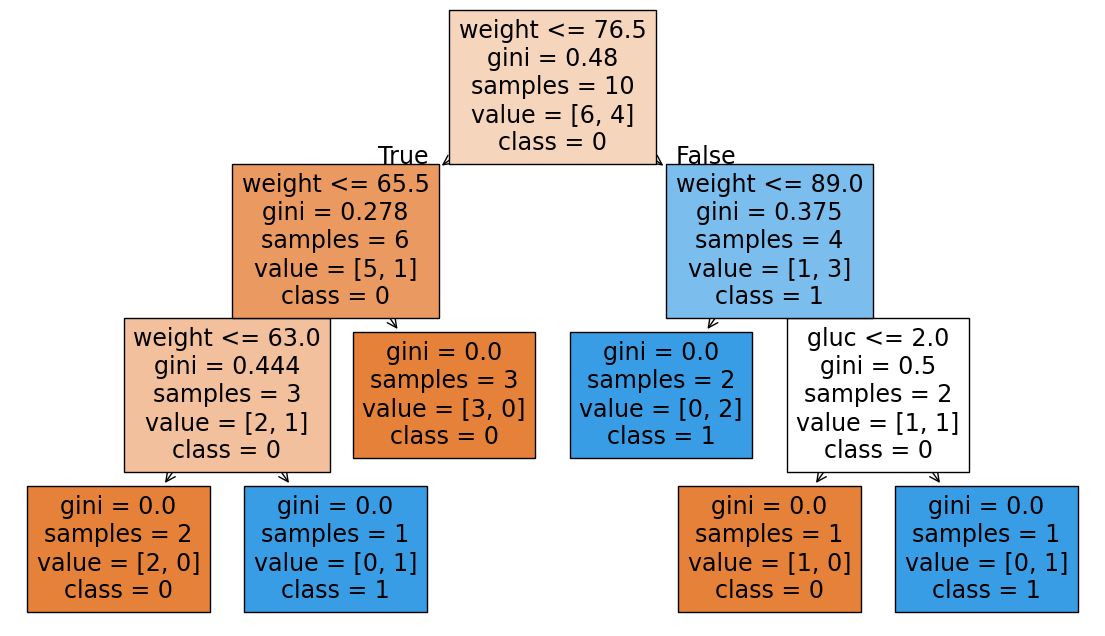

In [117]:
plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=features, class_names=['0', '1'], filled=True)
plt.show()

### 4.2 Получение второго вопроса


4.2.1. Глядя на df_left и df_right, посмотрите, где можно сделать ещё разбиение

In [118]:
current_df = df_right.copy()
print('Будем делать второе разбиение в df_right, потому что в этой подвыборке классы все еще смешаны')
current_df

Будем делать второе разбиение в df_right, потому что в этой подвыборке классы все еще смешаны


,weight,gluc,cardio
1,85.0,1,1
3,82.0,1,1
6,93.0,1,0
7,95.0,3,1


4.2.2. Пройдитесь по всем признакам в выбранной подвыборке

In [119]:
questions = []
for feature in features:
  for threshold in get_thresholds(current_df[feature]):
    left = current_df[current_df[feature] <= threshold]
    right = current_df[current_df[feature] > threshold]
    questions.append([
        feature,
        threshold,
        gain(left[target], right[target], current_df[target])
    ])
questions_df = pd.DataFrame(questions, columns=['feature', 'threshold', 'gain'])
questions_df.sort_values('gain', ascending=False)

,feature,threshold,gain
1,weight,89.0,0.125000
0,weight,83.5,0.041667
2,weight,94.0,0.041667
3,gluc,2.0,0.041667


4.2.3 Найдите самый лучший вопрос, опираясь на прирост информации

In [120]:
best_question = questions_df.sort_values('gain', ascending=False).iloc[0]
best_question

,1
feature,weight
threshold,89.0
gain,0.125


4.2.4. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [121]:
best_feature = best_question['feature']
best_threshold = best_question['threshold']
df_left = current_df[current_df[best_feature] <= best_threshold]
df_right = current_df[current_df[best_feature] > best_threshold]
df_left, df_right

(   weight  gluc  cardio
 1    85.0     1       1
 3    82.0     1       1,
    weight  gluc  cardio
 6    93.0     1       0
 7    95.0     3       1)

4.2.5. Проверьте себя через визуализацию дерева решений

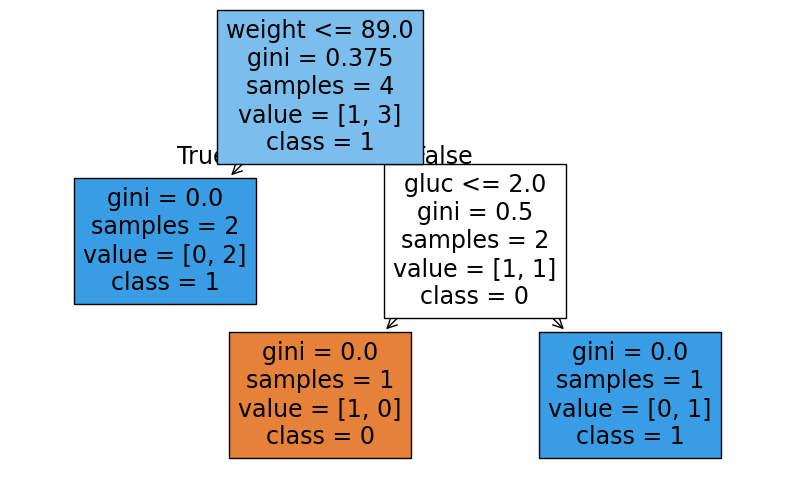

In [122]:
sub_clf = DecisionTreeClassifier(random_state=1)
sub_clf.fit(current_df[features], current_df[target])
plt.figure(figsize=(10, 6))
plot_tree(sub_clf, feature_names=features, class_names=['0', '1'], filled=True)
plt.show()

4.2.6. Если что-то не сошлось, посмотрите, в чем может быть проблема

In [124]:
problem_df = df_right.copy()
problem_df
questions = []
for feature in features:
  for threshold in get_thresholds(problem_df[feature]):
    left = problem_df[problem_df[feature] <= threshold]
    right = problem_df[problem_df[feature] > threshold]
    questions.append([
        feature,
        threshold,
        gain(left[target], right[target], problem_df[target])
    ])
pd.DataFrame(questions, columns=['feature', 'threshold', 'gain'])

,feature,threshold,gain
0,weight,94.0,0.5
1,gluc,2.0,0.5


Тут на самом деле ошибки нет. Просто есть два одинаково нормальных варианта разбиения: weight <= 94.0 и gluc <= 2.0. Поэтому вручную мог получиться один вариант, а у дерева на графике - другой. Это ок, потому что по качеству разбиения они одинаковые

# 2. Дерево решений для регрессии

In [125]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

### 1. Получение данных load_breat_cancer

Будем работать с набором данных для задачи регрессии `load_diabetes`, который можно получить из стандартных датасетов в `sklearn'e`.

После `load_diabetes()` возвращается словарь с данными (`data`), целевой переменной (`target`), названиями характеристик в данных (`feature_names`) и описанием данных (`DESCR`).

In [126]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [127]:
X = data.data
features = data.feature_names
y = data.target

Из признаков (характеристик данных) и целевой переменной сформируем датафрейм, в качестве названий колонок возьмем названия признаков.

In [128]:
df = pd.DataFrame(X, columns=features)
df['target'] = y
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Разобьем выборку на две: обучающую и тестовую.

In [129]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df['target'],
    test_size=0.2,
    shuffle=True,
    random_state=3
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((353, 10), (353,), (89, 10), (89,))

### 1.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [130]:
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor(random_state=1)
reg.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

### 1.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [131]:
from sklearn.metrics import mean_squared_error, r2_score
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)
print('MSE train:', mean_squared_error(y_train, y_train_pred))
print('MSE test:', mean_squared_error(y_test, y_test_pred))
print('R2 train:', r2_score(y_train, y_train_pred))
print('R2 test:', r2_score(y_test, y_test_pred))

MSE train: 0.0
MSE test: 5897.134831460674
R2 train: 1.0
R2 test: -0.08909766517566808


Сделайте вывод, насколько хорошо обучилась модель

In [132]:
print('На обучающей выборке дерево переобучилось: ошибка равна 0, а на тесте качество заметно хуже')

На обучающей выборке дерево переобучилось: ошибка равна 0, а на тесте качество заметно хуже


### 1.3. Изменение метрики

Попробуйте поизменять известные параметры для того, чтобы метрика стала лучше.

In [133]:
reg = DecisionTreeRegressor(random_state=1, max_depth=3, min_samples_leaf=20)
reg.fit(X_train, y_train)
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)
print('MSE train:', mean_squared_error(y_train, y_train_pred))
print('MSE test:', mean_squared_error(y_test, y_test_pred))
print('R2 train:', r2_score(y_train, y_train_pred))
print('R2 test:', r2_score(y_test, y_test_pred))

MSE train: 3018.3361025411696
MSE test: 3184.4741540074015
R2 train: 0.501069888964481
R2 test: 0.4118833187535116


In [134]:
print('После ограничения глубины и минимального размера листа дерево стало обобщать лучше на тестовой выборке')

После ограничения глубины и минимального размера листа дерево стало обобщать лучше на тестовой выборке


### 2. Получение данных make_regression

Для второго примера возьмем самодельный набор данных для задачи регрессии `make_regression`, который можно получить из стандартных датасетов в `sklearn'e`.

Сгенерируем себе 100к объектов, которые описываются 20 признаками, из них 12 будут дейтсвительно полезными.

In [136]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=100_000, n_features=20, n_informative=12, random_state=10)

In [137]:
X.shape, y.shape

((100000, 20), (100000,))

Разобьем выборку на две: обучающую и тестовую.

In [138]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=3
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80000, 20), (80000,), (20000, 20), (20000,))

### 2.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [139]:
reg = DecisionTreeRegressor(random_state=1)
reg.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

### 2.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [140]:
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)
print('MSE train:', mean_squared_error(y_train, y_train_pred))
print('MSE test:', mean_squared_error(y_test, y_test_pred))
print('R2 train:', r2_score(y_train, y_train_pred))
print('R2 test:', r2_score(y_test, y_test_pred))

MSE train: 0.0
MSE test: 16649.860589567856
R2 train: 1.0
R2 test: 0.6916004851223545


Сделайте вывод, насколько хорошо обучилась модель

In [141]:
print('На обучающей выборке дерево снова переобучилось, но на тестовой выборке качество уже заметно лучше, чем в предыдущем наборе данных.')

На обучающей выборке дерево снова переобучилось, но на тестовой выборке качество уже заметно лучше, чем в предыдущем наборе данных.


### 2.3. Перебор гиперпараметров

Осуществите перебор параметров для получения лучших результатов (GridSearchCV, см. подход из п.0).

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [10, 12, 15],
    'min_samples_leaf': [1, 5]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=1),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_reg = grid.best_estimator_
y_train_pred = best_reg.predict(X_train)
y_test_pred = best_reg.predict(X_test)

print('Лучшие параметры:', grid.best_params_)
print('MSE train:', mean_squared_error(y_train, y_train_pred))
print('MSE test:', mean_squared_error(y_test, y_test_pred))
print('R2 train:', r2_score(y_train, y_train_pred))
print('R2 test:', r2_score(y_test, y_test_pred))


In [ ]:
print('После перебора гиперпараметров качество на тестовой выборке стало лучше.')
